---
title: Nearest Neighbor Model
author: Andrei Akopian
date: 2026-01-28
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

An attempt to use a KNN model (Sklearn's builtin) for abundance predictions.

We found that cosine distance works better than $L_2$ distance, and k=5 is the optimal number of neighbors (however, the $k$ hyperparameter is unstable and tends to shift between 2 and 7 depending on train-test splits.)

The models presented here are extremely simple, and most cells should execute in a few seconds on personal computers. Cells that take longer are marked as such.

The notebook has two parts, the first analyzes lab data, and the second the atmospherically modelled data.

In [16]:
import numpy as np
import pandas as pd
import pathlib
import scipy
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [3]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [4]:
LAB_DATA = "../../../data/useful_columns_data.csv"
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"

In [5]:
df = helper_functions.open_file(LAB_DATA)
fractions, nr900to1700 = helper_functions.take_subset(df,start=900,end=1700)

# Basic KNN on Lab Data

The $R^2$ values are low compared to our Linear Regression baseline. 

Histograms of the predicted abundaces reveal that KNN is being excessively conservative: **skew towards the center**, while the actual distribution is much more unifrom.

The k=5 with an R² of 0.7546
- npv with an R² of 0.6526187826312486
- gv with an R² of 0.8369184476606242
- soil with an R² of 0.7743126991036591
rmse = 0.15090411355305108


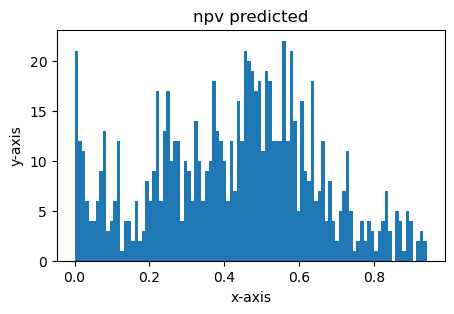

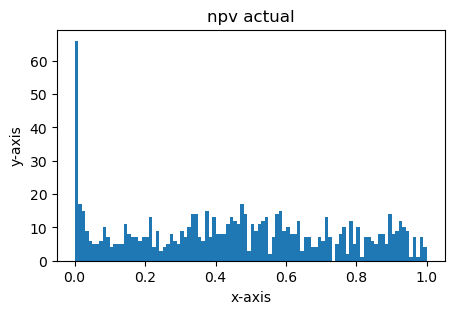

In [12]:
# Normal KNN regression
# should take <1min to run
X_train, X_test, y_train, y_test = train_test_split(nr900to1700, fractions, test_size=0.5, random_state=42)

K=5
knn = KNeighborsRegressor(n_neighbors=K, metric='cosine')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
current_r2 = r2_score(y_test, y_pred)

print(f"The k={K} with an R² of {current_r2:.4f}")
helper_functions.simple_histogram([y[0] for y in y_pred], title='npv predicted', bins=100)
helper_functions.simple_histogram([y_test.loc[i, 'npv_fraction'] for i in y_test.index], title='npv actual', bins=100)
# helper_functions.simple_histogram([y[1] for y in y_pred], title='gv predicted', bins=100)
# helper_functions.simple_histogram([y[2] for y in y_pred], title='soil predicted', bins=100)
print("- npv with an R² of", r2_score(y_test['npv_fraction'], [p[0] for p in y_pred]))
print("- gv with an R² of", r2_score(y_test['gv_fraction'], [p[1] for p in y_pred]))
print("- soil with an R² of", r2_score(y_test['soil_fraction'], [p[2] for p in y_pred]))
rmse = root_mean_squared_error(y_test, y_pred)
print(f"rmse = {rmse}")

Here is a ternary plot of the abudnaces output by the Basic KNN model. For actual see [Dataset Characterization](../characterization/dataset_characterization.ipynb).

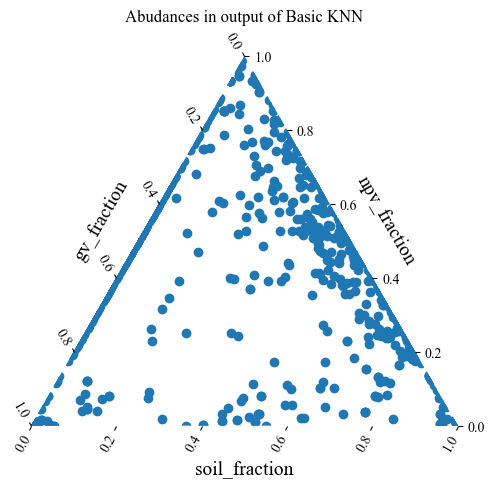

In [6]:
helper_functions.ternary_abundances(y_pred, model_name="Basic KNN")

## Finding Best KNN hyperparameters

Above we used $k=5$ and cosine definition of distance without justification. Here sklearn's GridSearchCV finding these as the best hyperparameters best values. KNNs $r^2$ on lab data is not significantly worse than Linear Regression.

In [8]:
# should take <1 min to run
X_train, X_test, y_train, y_test = train_test_split(nr900to1700, fractions, test_size=0.5, random_state=42)
gs = GridSearchCV(
    KNeighborsRegressor(),
    cv=10,
    param_grid={
        "n_neighbors": range(1,14),
        "metric": ['cosine', 'minkowski'],
    },
)
gs.fit(X_train, y_train)
print(f"Best Parameters: {gs.best_params_}")
print(f"Best Extimator R^2: {gs.best_estimator_.score(X_test, y_test)}")

Best Parameters: {'metric': 'cosine', 'n_neighbors': 5}
Best Extimator R^2: 0.7546166431318438


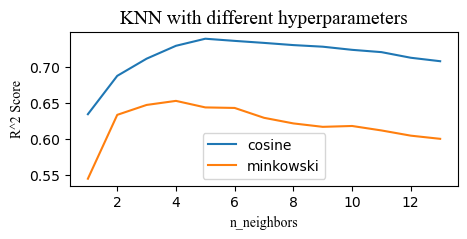

In [13]:
# Adapted from: https://scikit-learn.org/stable/auto_examples/model_selection/plot_multi_metric_evaluation.html#running-gridsearchcv-using-multiple-evaluation-metrics
results = gs.cv_results_
FONT_NAME = 'Times New Roman'
plt.figure(figsize=(5, 2))
plt.title("KNN with different hyperparameters", fontname=FONT_NAME, fontsize=14)

plt.xlabel("n_neighbors", fontname=FONT_NAME)
plt.ylabel("R^2 Score", fontname=FONT_NAME)

ax = plt.gca()

# Get the regular numpy array from the MaskedArray
X_axis = list(set(results["param_n_neighbors"].data))

sample_score_mean = results["mean_test_score"].data
cosine_results = [y for i, y in enumerate(sample_score_mean) if results["param_metric"].data[i] == "cosine"]
minkowski_results = [y for i, y in enumerate(sample_score_mean) if results["param_metric"].data[i] == "minkowski"]
ax.plot(
    X_axis,
    cosine_results,
    label="cosine"
)
ax.plot(
    X_axis,
    minkowski_results,
    label="minkowski",
)
plt.legend()
plt.show()

Below is the prediction plot. The overfitting towards the center is extremely obvious.

There is probably some nice solution for resolving this by chaning the distance definitions, and transforming data correctly.

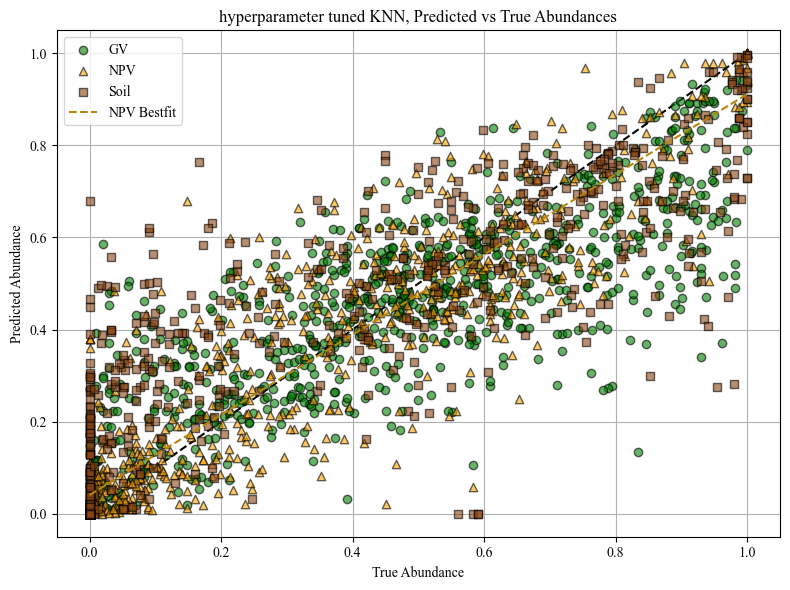

In [14]:
helper_functions.plot_preds(
    ab_true = y_test.to_numpy(),
    ab_pred = gs.best_estimator_.predict(X_test),
    save_path = "hyperparameter_tuned_knn.svg",
    model_name = "hyperparameter tuned KNN"
)

### Normalized (L1) Lab Data

In [6]:
df = helper_functions.open_file(LAB_DATA)
fractions, lb900to1700_raw = helper_functions.take_subset(df,start=900,end=1700)

In [22]:
dataset = lb900to1700_raw
# norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
norms = dataset.sum(axis=1).to_numpy()
print(norms.min(), norms.max())
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
# post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
post_norms = normalized_dataset.sum(axis=1)
print(post_norms.min(), post_norms.max())
lbr900to1700 = normalized_dataset

8.705963602199999 45.08746808780001
0.9999999999999989 1.0000000000000013


In [9]:
X_train, X_test, y_train, y_test = train_test_split(lbr900to1700, fractions.to_numpy(), test_size=0.2, random_state=42)

In [27]:
knn_normalized = KNeighborsRegressor(n_neighbors=5, metric='euclidean')
knn_normalized.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [28]:
predictions = knn_normalized.predict(X_test)
slope, intercept, r, p, se = scipy.stats.linregress(y_test, predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")
rmse = root_mean_squared_error(y_test, predictions)
print(f"rmse = {rmse}")

npv r^2 = 0.743220107730547
gv r^2 = 0.8379163620459784
soil r^2 = 0.8353963447855458
mean r^2 = 0.8055109381873571
rmse = 0.1355267532695928


# Atmospheric Data
The modeled data has several problems. See [Dataset Characterization](../characterization/dataset_characterization.ipynb) for more specific information.

Primary limitation is a small number of rows available for training.

In [11]:
df = helper_functions.open_file(ATMO_DATA)
fractions, at900to1690 = helper_functions.take_subset(df,start=900,end=1690)
vza = df["VZA"]

The k=5 with an R² of 0.1957
- npv with an R² of -0.206522458756899
- gv with an R² of 1.0
- soil with an R² of -0.20652245875689923


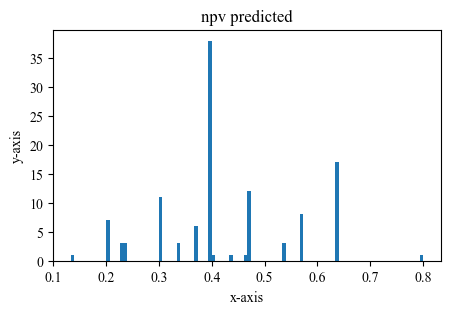

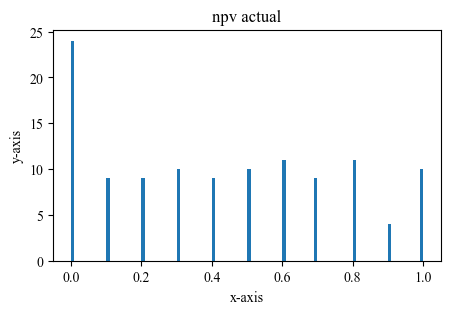

In [12]:
# Normal KNN regression
# should take <1min to run
X_train, X_test, y_train, y_test = train_test_split(at900to1690, fractions, test_size=0.8, random_state=42)

k=5
knn = KNeighborsRegressor(n_neighbors=3, metric='cosine')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
current_r2 = r2_score(y_test, y_pred)

print(f"The k={k} with an R² of {current_r2:.4f}")
helper_functions.simple_histogram([y[0] for y in y_pred], title='npv predicted', bins=100)
helper_functions.simple_histogram([y_test.loc[i, 'npv_fraction'] for i in y_test.index], title='npv actual', bins=100)
# helper_functions.simple_histogram([y[1] for y in y_pred], title='gv predicted', bins=100)
# helper_functions.simple_histogram([y[2] for y in y_pred], title='soil predicted', bins=100)
print("- npv with an R² of", r2_score(y_test['npv_fraction'], [p[0] for p in y_pred]))
print("- gv with an R² of", r2_score(y_test['gv_fraction'], [p[1] for p in y_pred]))
print("- soil with an R² of", r2_score(y_test['soil_fraction'], [p[2] for p in y_pred]))

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/Users/andrei/.local/share/mamba/envs/plswork/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

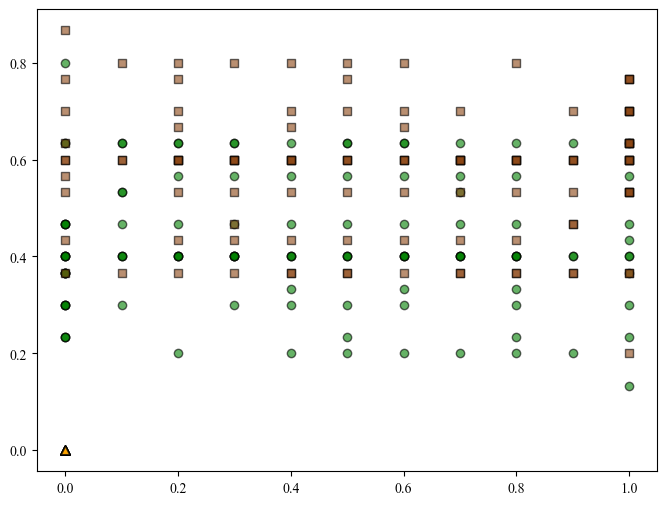

In [13]:
helper_functions.plot_preds(
    ab_true = y_test.to_numpy(),
    ab_pred = y_pred,
    save_path = "hyperparameter_tuned_knn.svg",
    model_name = "hyperparameter tuned KNN"
)

### Finding Best KNN parameters (atmo data)

It appears that the $R^2$ is unstable. So we will do a lot of splits and take the average.

In [26]:
# should take <1 min to run
X_train, X_test, y_train, y_test = train_test_split(at900to1690, fractions, test_size=0.2, random_state=42)
gs = GridSearchCV(
    KNeighborsRegressor(),
    cv=2,
    param_grid={
        "n_neighbors": range(1,14),
        "metric": ['cosine', 'minkowski'],
    },
)
gs.fit(X_train, y_train)
print(f"Best Parameters: {gs.best_params_}")
print(f"Best Extimator R^2: {gs.best_estimator_.score(X_test, y_test)}")

y_pred = gs.best_estimator_.predict(X_test)
current_r2 = r2_score(y_test, y_pred)
print("- npv with an R² of", r2_score(y_test['npv_fraction'], [p[0] for p in y_pred]))
print("- gv with an R² of", r2_score(y_test['gv_fraction'], [p[1] for p in y_pred]))
print("- soil with an R² of", r2_score(y_test['soil_fraction'], [p[2] for p in y_pred]))
rmse = root_mean_squared_error(y_test, y_pred)
print(f"rmse = {rmse}")

Best Parameters: {'metric': 'minkowski', 'n_neighbors': 4}
Best Extimator R^2: 0.3047443411479385
- npv with an R² of -0.04288348827809241
- gv with an R² of 1.0
- soil with an R² of -0.042883488278092186
rmse = 0.23353849765093862


In [ ]:
def check_random_state(random_state: int = 42) -> tuple[float]:
    X_train, X_test, y_train, y_test = train_test_split(at900to1690, fractions, test_size=0.2, random_state=random_state)
    knn = KNeighborsRegressor(n_neighbors=11, metric='minkowski')
    # gs = GridSearchCV(
    #     KNeighborsRegressor(),
    #     cv=2,
    #     param_grid={
    #         "n_neighbors": range(1,14),
    #         "metric": ['cosine', 'minkowski'],
    #     },
    # )
    # gs.fit(X_train, y_train)
    # print(gs.best_params_)
    # y_pred = gs.best_estimator_.predict(X_test)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    npvr2 = r2_score(y_test['npv_fraction'], [p[0] for p in y_pred])
    gvr2 = r2_score(y_test['gv_fraction'], [p[1] for p in y_pred])
    soilr2 = r2_score(y_test['soil_fraction'], [p[2] for p in y_pred])
    rmse = root_mean_squared_error(y_test, y_pred)
    return npvr2, gvr2, soilr2, rmse

In [ ]:
N = 1000  # takes 2.8s
npvr2s = []
gvr2s = []
soilr2s = []
rmses = []
for state in range(0, N):
    # print(f"== State {state} ==")
    npvr2, gvr2, soilr2, rmse = check_random_state(state)
    npvr2s.append(npvr2)
    gvr2s.append(gvr2)
    soilr2s.append(soilr2)
    rmses.append(rmse)

In [41]:
print("avg NPV r2:", sum(npvr2s) / N)
print("avg GV r2:", sum(gvr2s) / N)
print("avg SOIL r2:", sum(soilr2s) / N)
# print("avg mean r2:", (sum(npvr2s) + sum(gvr2s) + sum(soilr2s)) / N / 3)
print("avg mean r2:", (sum(npvr2s) + sum(soilr2s)) / N / 2)
print("avg RMSE:", sum(rmses) / N)

avg NPV r2: -0.08024395984966026
avg GV r2: 1.0
avg SOIL r2: -0.08024395984966029
avg mean r2: -0.08024395984966028
avg RMSE: 0.22432707771381755


We will report $R^2 = $ as finall KNN for atmo data is $0.27983$
and npv-$R^2$ is $-0.08024$ and rmse=0.2243

### Pre-Training on Lab Data
The Baysian and deep learning models, were able to benefit from som pre-training on Lab Data. Here are some amatur attempts to use a similar strategy for KNN.

In [14]:
lbdf = helper_functions.open_file(LAB_DATA)
lbfractions, lb900to1690_raw = helper_functions.take_subset(lbdf,start=900,end=1690)
atdf = helper_functions.open_file(ATMO_DATA)
atfractions, at900to1690_raw = helper_functions.take_subset(atdf,start=900,end=1690)

In [15]:
# L2 norm on lab data
dataset = lb900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
lb900to1690 = normalized_dataset

L1 before normalization: min=1.0853925339623511 max=4.995320587151579
L1 after normalization: min=0.9999999999999994 max=1.0000000000000007


In [16]:
# L2 norm on atmo data
dataset = at900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
at900to1690 = normalized_dataset

L1 before normalization: min=0.07422868006799167 max=5.547629854271101
L1 after normalization: min=0.9999999999999996 max=1.0000000000000002


The k=11 with an R² of -0.5279
- npv with an R² of -0.5822685162321766
- gv with an R² of 0.0
- soil with an R² of -1.001303415849871
rmse = 0.3282518623477861


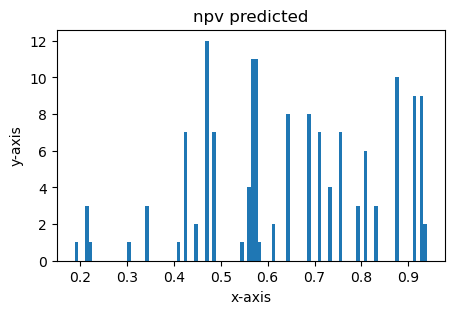

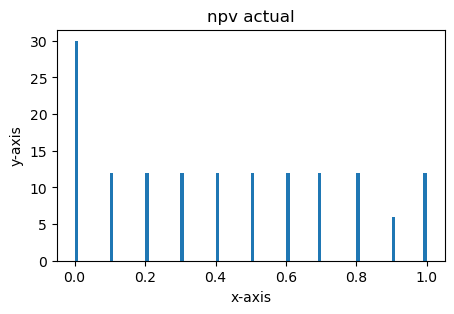

In [17]:
# Normal KNN regression
# should take <1min to run
X_train, X_test, y_train, y_test = lb900to1690, at900to1690, lbfractions, atfractions

K=11
knn = KNeighborsRegressor(n_neighbors=K, metric='cosine')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
current_r2 = r2_score(y_test, y_pred)

print(f"The k={K} with an R² of {current_r2:.4f}")
helper_functions.simple_histogram([y[0] for y in y_pred], title='npv predicted', bins=100)
helper_functions.simple_histogram([y_test.loc[i, 'npv_fraction'] for i in y_test.index], title='npv actual', bins=100)
# helper_functions.simple_histogram([y[1] for y in y_pred], title='gv predicted', bins=100)
# helper_functions.simple_histogram([y[2] for y in y_pred], title='soil predicted', bins=100)
print("- npv with an R² of", r2_score(y_test['npv_fraction'], [p[0] for p in y_pred]))
print("- gv with an R² of", r2_score(y_test['gv_fraction'], [p[1] for p in y_pred]))
print("- soil with an R² of", r2_score(y_test['soil_fraction'], [p[2] for p in y_pred]))
rmse = root_mean_squared_error(y_test, y_pred)
print(f"rmse = {rmse}")